# Comparação de Métodos Numéricos

Este notebook tem como objetivo determinar o valor de entrada `n` em que os algoritmos A e B apresentam o mesmo tempo de execução.

As funções que representam os tempos de execução são:

$$
T_A(n) = 0.01n\log_2(n)
$$

$$
T_B(n) = 0.08n + 20
$$

Para determinar o ponto em que os tempos são iguais, buscamos a raiz da função:

$$
f(n) = T_A(n) - T_B(n)
$$

ou seja:

$$
f(n) = 0.01n\log_2(n) - 0.08n - 20
$$

In [14]:
import math
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
def TA(n):
    return 0.01 * n * math.log2(n)

def TB(n):
    return 0.08 * n + 20

def f(n):
    return TA(n) - TB(n)

## Identificação do Intervalo

Antes da aplicação dos métodos numéricos, é necessário identificar uma região em que ocorre a mudança de sinal da função $f(n)$.

Uma mudança de sinal indica a existência de uma raiz no intervalo analisado.

In [16]:
print("n = 10:", f(10))
print("n = 100:", f(100))
print("n = 1000:", f(1000))

n = 10: -20.467807190511266
n = 100: -21.356143810225277
n = 1000: -0.34215715337913366


In [17]:
for n in range(1, 10001):
    if f(n) * f(n + 1) < 0:
        print(f"Mudança de sinal entre n = {n} e n = {n + 1}")

Mudança de sinal entre n = 1010 e n = 1011


## Critérios de Parada e Precisão

Para a execução dos três métodos numéricos, foram utilizadas tolerâncias de:

$$
\varepsilon_1 = \varepsilon_2 = 10^{-6}
$$

e um número máximo de 100 iterações.

O critério $\varepsilon_1$ é utilizado para avaliar a diferença entre as aproximações ou o tamanho do intervalo, enquanto $\varepsilon_2$ verifica o valor do resíduo $|f(n)|$.

A precisão de $10^{-6}$ foi escolhida para garantir uma aproximação suficientemente precisa da raiz, permitindo comparar os métodos sob os mesmos critérios de tolerância.

O limite de 100 iterações foi utilizado como condição de segurança para evitar execuções indefinidas caso algum método não atingisse a tolerância estabelecida.

## Método da Posição Falsa

O Método da Posição Falsa será aplicado utilizando o intervalo $[1010, 1011]$, no qual foi identificada uma mudança de sinal da função.

In [18]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "src"))

from metodos.posicao_falsa import posicao_falsa

In [19]:
raiz_pf, iteracoes_pf = posicao_falsa(
    f,
    1010,
    1011,
    1e-6,
    1e-6,
    100
)

print("Método da Posição Falsa")
print("n encontrado:", raiz_pf)
print("Iterações:", iteracoes_pf)
print("Resíduo:", abs(f(raiz_pf)))

Método da Posição Falsa
n encontrado: 1010.0172413456174
Iterações: 1
Resíduo: 1.2097495982743567e-07


### Resultado - Método da Posição Falsa

O Método da Posição Falsa encontrou a raiz aproximada:

$$
n \approx 1010.017241
$$

O método convergiu em **1 iteração**, apresentando resíduo de aproximadamente:

$$
1.21 \times 10^{-7}
$$

Como o resíduo obtido é inferior à tolerância estabelecida de $10^{-6}$, o resultado satisfaz o critério de precisão utilizado.

Esse valor representa aproximadamente o tamanho de entrada em que os algoritmos A e B apresentam o mesmo tempo de execução.

## Método da Bisseção

O Método da Bisseção será aplicado utilizando o mesmo intervalo $[1010, 1011]$ e os mesmos critérios de parada utilizados na Posição Falsa.

In [20]:
from metodos.bissecao import bissecao

In [21]:
raiz_bis, iteracoes_bis = bissecao(
    f,
    1010,
    1011,
    1e-6,
    1e-6,
    100
)

print("Método da Bisseção")
print("n encontrado:", raiz_bis)
print("Iterações:", iteracoes_bis)
print("Resíduo:", abs(f(raiz_bis)))

Método da Bisseção
n encontrado: 1010.0172729492188
Iterações: 14
Resíduo: 9.607718425286293e-07


### Resultado - Método da Bisseção

O Método da Bisseção encontrou a raiz aproximada:

$$
n \approx 1010.0172729492188
$$

O método convergiu em **14 iterações**, apresentando resíduo de aproximadamente:

$$
9.607718425286293e-07
$$

Como o resíduo obtido é inferior à tolerância estabelecida de $10^{-6}$, o resultado satisfaz o critério de precisão utilizado.

O valor encontrado representa aproximadamente o tamanho de entrada em que os algoritmos A e B apresentam o mesmo tempo de execução.

## Método de Newton-Raphson

O Método de Newton-Raphson necessita da derivada da função $f(n)$.

Considerando:

$$
f(n) = 0.01n\log_2(n) - 0.08n - 20
$$

sua derivada é:

$$
f'(n) =
0.01\left(\log_2(n) + \frac{1}{\ln(2)}\right) - 0.08
$$

Como valor inicial, foi utilizado o ponto médio do intervalo $[1010,1011]$:

$$
x_0 = 1010.5
$$

In [22]:
from metodos.newton_raphson import newton_raphson

In [23]:
def df(n):
    return 0.01 * (math.log2(n) + 1 / math.log(2)) - 0.08

In [24]:
raiz_newton, iteracoes_newton = newton_raphson(
    f,
    df,
    1010.5,
    1e-6,
    1e-6,
    100
)

print("Método de Newton-Raphson")
print("n encontrado:", raiz_newton)
print("Iterações:", iteracoes_newton)
print("Resíduo:", abs(f(raiz_newton)))

Método de Newton-Raphson
n encontrado: 1010.0172448799425
Iterações: 2
Resíduo: 2.842170943040401e-14


### Resultado - Método de Newton-Raphson

O Método de Newton-Raphson encontrou a raiz aproximada:

$$
n \approx 1010.017245
$$

O método convergiu em **2 iterações**, apresentando resíduo de aproximadamente:

$$
2.84 \times 10^{-14}
$$

Como o resíduo obtido é inferior à tolerância estabelecida de $10^{-6}$, o resultado satisfaz o critério de precisão utilizado.

O valor encontrado representa aproximadamente o tamanho de entrada em que os algoritmos A e B apresentam o mesmo tempo de execução.

## Comparação dos Métodos

A tabela abaixo apresenta os resultados obtidos pelos três métodos numéricos utilizando tolerâncias de $10^{-6}$.

In [25]:
resultados = pd.DataFrame({
    "Método": [
        "Bisseção",
        "Posição Falsa",
        "Newton-Raphson"
    ],
    "Raiz aproximada": [
        raiz_bis,
        raiz_pf,
        raiz_newton
    ],
    "Iterações": [
        iteracoes_bis,
        iteracoes_pf,
        iteracoes_newton
    ],
    "Resíduo": [
        abs(f(raiz_bis)),
        abs(f(raiz_pf)),
        abs(f(raiz_newton))
    ]
})

resultados

,Método,Raiz aproximada,Iterações,Resíduo
0,Bisseção,1010.017273,14,9.607718e-07
1,Posição Falsa,1010.017241,1,1.209750e-07
2,Newton-Raphson,1010.017245,2,2.842171e-14


## Comparação dos Tempos de Execução

O gráfico a seguir apresenta as funções $T_A(n)$ e $T_B(n)$ nas proximidades da raiz encontrada pelos métodos numéricos.

O ponto de interseção representa o tamanho de entrada em que os dois algoritmos apresentam aproximadamente o mesmo tempo de execução.

In [26]:
import numpy as np

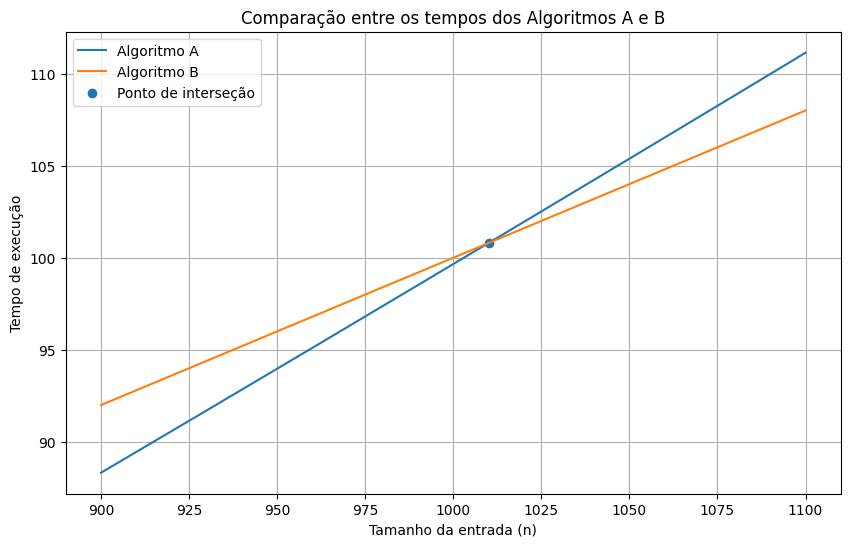

In [27]:
n_valores = np.linspace(900, 1100, 500)

ta_valores = [TA(n) for n in n_valores]
tb_valores = [TB(n) for n in n_valores]

plt.figure(figsize=(10, 6))

plt.plot(n_valores, ta_valores, label="Algoritmo A")
plt.plot(n_valores, tb_valores, label="Algoritmo B")

plt.scatter(
    raiz_newton,
    TA(raiz_newton),
    label="Ponto de interseção"
)

plt.xlabel("Tamanho da entrada (n)")
plt.ylabel("Tempo de execução")
plt.title("Comparação entre os tempos dos Algoritmos A e B")

plt.legend()
plt.grid()

plt.show()

## Comparação do Número de Iterações

O gráfico a seguir compara a quantidade de iterações necessárias para que cada método atingisse o critério de parada estabelecido.

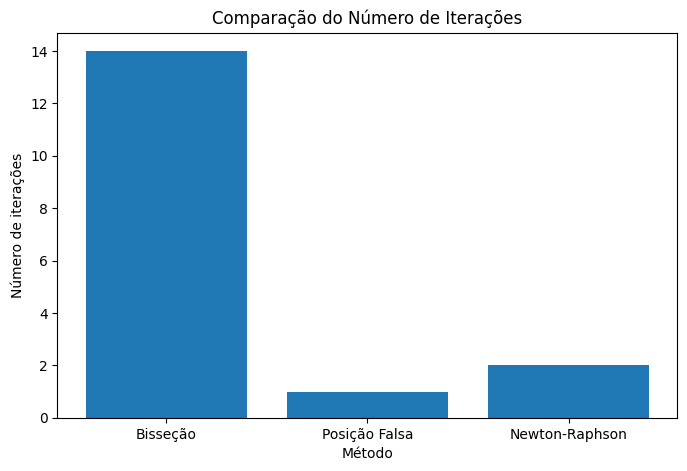

In [28]:
metodos = ["Bisseção", "Posição Falsa", "Newton-Raphson"]

iteracoes = [
    iteracoes_bis,
    iteracoes_pf,
    iteracoes_newton
]

plt.figure(figsize=(8, 5))

plt.bar(metodos, iteracoes)

plt.xlabel("Método")
plt.ylabel("Número de iterações")
plt.title("Comparação do Número de Iterações")

plt.show()

## Análise do Desempenho dos Algoritmos

Os métodos numéricos indicaram que os tempos de execução dos algoritmos A e B se igualam aproximadamente em:

$$
n \approx 1010.017
$$

Para verificar qual algoritmo apresenta menor tempo de execução antes e depois desse ponto, são analisados valores inteiros próximos à raiz.

In [30]:
for n in [1009, 1010, 1011, 1012]:
    print(
        f"n = {n} | "
        f"TA(n) = {TA(n):.6f} | "
        f"TB(n) = {TB(n):.6f}"
    )

n = 1009 | TA(n) = 100.685189 | TB(n) = 100.720000
n = 1010 | TA(n) = 100.799410 | TB(n) = 100.800000
n = 1011 | TA(n) = 100.913645 | TB(n) = 100.880000
n = 1012 | TA(n) = 101.027895 | TB(n) = 100.960000


A análise dos valores antes e depois do ponto de interseção mostra que:

- Para $n < 1010.017$, temos $T_A(n) < T_B(n)$, portanto o **Algoritmo A apresenta menor tempo de execução**.
- Em $n \approx 1010.017$, temos $T_A(n) = T_B(n)$, representando o ponto de interseção entre os dois algoritmos.
- Para $n > 1010.017$, temos $T_B(n) < T_A(n)$, portanto o **Algoritmo B apresenta menor tempo de execução**.

Como o tamanho da entrada `n` é considerado inteiro, na prática:

- para $n \leq 1010$, o **Algoritmo A** apresenta menor tempo de execução;
- para $n \geq 1011$, o **Algoritmo B** apresenta menor tempo de execução.

## Comparação Final

Os três métodos numéricos encontraram valores muito próximos para a raiz da função, indicando que o ponto em que os algoritmos A e B apresentam o mesmo tempo de execução ocorre aproximadamente em:

$$
n \approx 1010.017
$$

Considerando os critérios de parada utilizados, o **Método da Bisseção** necessitou de 14 iterações e apresentou resíduo de aproximadamente $9.61 \times 10^{-7}$. O método apresentou convergência dentro da tolerância estabelecida, porém necessitou de mais iterações que os demais métodos.

O **Método da Posição Falsa** necessitou de apenas 1 iteração e apresentou resíduo de aproximadamente $1.21 \times 10^{-7}$. Para o intervalo utilizado neste problema, o método atingiu rapidamente o critério de parada.

O **Método de Newton-Raphson** necessitou de 2 iterações e apresentou o menor resíduo entre os três métodos, aproximadamente $2.84 \times 10^{-14}$, obtendo uma aproximação extremamente próxima da raiz.

Os resultados mostram que os três métodos convergiram para praticamente a mesma solução, porém apresentaram diferenças no número de iterações e no resíduo final. Neste experimento específico, a Posição Falsa atingiu o critério de parada com o menor número de iterações, enquanto Newton-Raphson apresentou o menor resíduo.

É importante observar que esses resultados dependem das condições iniciais utilizadas. A Bisseção e a Posição Falsa utilizaram o intervalo $[1010,1011]$, enquanto Newton-Raphson utilizou $x_0 = 1010.5$.

Portanto, o ponto de equilíbrio entre os tempos de execução dos dois algoritmos ocorre aproximadamente em:

$$
n \approx 1010.017
$$

Considerando que o tamanho da entrada é representado por valores inteiros, para $n \leq 1010$ o **Algoritmo A apresenta menor tempo de execução**, enquanto para $n \geq 1011$ o **Algoritmo B apresenta menor tempo de execução**.

Dessa forma, os três métodos numéricos convergiram para a mesma região de solução e permitiram determinar tanto o ponto de interseção quanto as faixas de entrada em que cada algoritmo apresenta o menor tempo de execução.